In [7]:
import pandas as pd

data = pd.read_csv("clean_house_data.csv")

In [8]:
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,renovated,price_per_sqft
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,5650,71,0,188.050847
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,7639,75,1,209.338521
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,8062,93,0,233.766234
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,5000,61,0,308.163265
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,7503,39,0,303.571429


In [9]:
from sklearn.neighbors import NearestNeighbors

coords = data[['lat', 'long']]

knn = NearestNeighbors(
    n_neighbors=6,
    metric='euclidean'
)

knn.fit(coords)

distances, indices = knn.kneighbors(coords)

In [10]:
edges = []

for i in range(len(indices)):
    for j in indices[i][1:]:
        edges.append((i, j))

In [11]:
print(edges[:10])

[(0, np.int64(6320)), (0, np.int64(16895)), (0, np.int64(5809)), (0, np.int64(2382)), (0, np.int64(5407)), (1, np.int64(16459)), (1, np.int64(13018)), (1, np.int64(2099)), (1, np.int64(19422)), (1, np.int64(342))]


In [13]:
%pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [15]:
import networkx as nx

G = nx.Graph()

G.add_nodes_from(range(len(data)))

G.add_edges_from(edges)

print(G)

Graph with 21613 nodes and 67465 edges


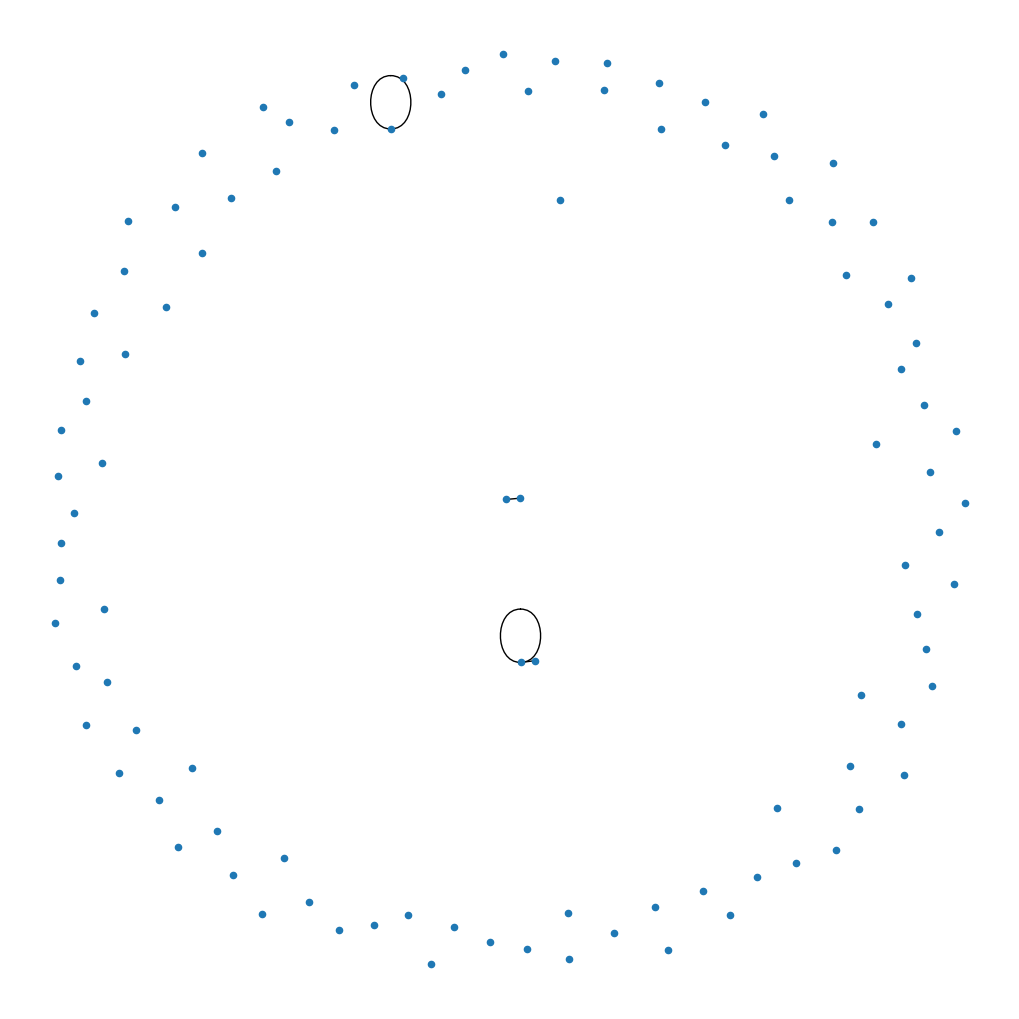

In [16]:
import matplotlib.pyplot as plt

small_graph = G.subgraph(range(100))

plt.figure(figsize=(10,10))

nx.draw(
    small_graph,
    node_size=20,
    with_labels=False
)

plt.show()

In [18]:
feature_columns = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'grade',
    'sqft_above',
    'sqft_basement'
]

X = data[feature_columns]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [3]:
%pip install torch torch-geometric

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
   ---------------------------------------- 1.3/122.0 MB 8.4 MB/s eta 0:00:15
    --------------------------------------- 2.4/122.0 MB 6.1 MB/s eta 0:00:20
    --------------------------------------- 2.9/122.0 MB 5.1 MB/s eta 0:00:24
    --------------------------------------- 2.9/122.0 MB 5.1 MB/s eta 0:00:24
   - -------------------------------------- 3.1/122.0 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 3.1/122.0 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 3.1/122.0 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 3.1/122.0 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 3.1/122.0 MB 3.2 MB/s eta 0:00:38
   - -------------------------------------- 3.1/122.0 MB 3.2 MB/s eta 0:00:38
   - -------------------

In [8]:
import torch
from torch_geometric.data import Data

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

x = torch.tensor(X_scaled, dtype=torch.float)

y = torch.tensor(data['price'].values, dtype=torch.float)

graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

print(graph_data)

Data(x=[21613, 11], edge_index=[2, 108065], y=[21613])


In [10]:
torch.save(
    graph_data,
    "G:\infotact_2\data\housing_graph.pt"
)